# 05 — Concentration Similarity Index (Byrne 2024)

Builds the network daily matrix from cleaned, humidity-corrected data, computes the pairwise CSI, and produces the fault-candidate ranking, heatmap, map and distance plot.

Changes from the first run:
* sensors with **< `MIN_VALID_DAYS` valid days are dropped** before the CSI (the 100-day rule justified in notebook 04) — short records made the similarity ranking coverage-biased
* short sensor codes come from a **regex** (fixes `SL_017` rendering as bare `SL`)
* the ranking now reports **n_pairs and median overlap days** alongside mean CSI

Requires in `src/config.py` (csi.py falls back to these values if absent):
```python
CSI_PM_LIM          = 15.0   # Byrne 2024 PM_lim (ug/m3)
CSI_C_UPPER         = 0.2    # C_lim,upper — strict regime above PM_lim
CSI_C_LOWER         = 0.7    # C_lim,lower — lenient regime below PM_lim
MIN_COMMON_DAYS = 30       # min overlapping days for a pair to count
MIN_READINGS_PER_DAY = 180   # (already present) daily-mean completeness
MIN_VALID_DAYS       = 100   # min valid days for a sensor to enter the CSI
```

In [1]:
import re
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from src.config import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.cleaning import apply_humidity_correction
from src.csi import csi_matrix, sensor_ranking

try:
    MIN_VALID_DAYS
except NameError:
    MIN_VALID_DAYS = 100   # fallback until added to config.py

def short_code(name: str) -> str:
    """'SL_017_-_Boston_Spa...' -> 'SL017'; 'SL001_Sunnyview...' -> 'SL001'."""
    m = re.search(r"SL_?(\d+)", str(name))
    return f"SL{int(m.group(1)):03d}" if m else str(name)

### Clean rows → Barkjohn correction → daily means → network matrix

Rows without RH are dropped before the daily mean (they can't be corrected), and the `MIN_READINGS_PER_DAY` completeness check runs on the post-drop count. For sensors with patchy RH (SL006 at 55% is the extreme case) the daily means therefore come from a subset of each day — flagged in the printout so it isn't silent.

In [2]:
daily_series = {}
rows = []

for path in sorted(CLEANED.glob("*.parquet")):
    name  = path.stem
    df    = pd.read_parquet(path)
    clean = df[df["is_clean"]].copy()
    if clean.empty:
        continue

    n_before = len(clean)
    clean[DATE_COL]    = pd.to_datetime(clean[DATE_COL])
    clean["pm25_corr"] = apply_humidity_correction(clean)
    clean = clean.dropna(subset=["pm25_corr"])          # rows without RH
    rh_loss = 1 - len(clean) / n_before
    if rh_loss > 0.05:
        print(f"  ! {name}: {rh_loss:.0%} of clean rows lack RH — "
              f"daily means use a subset of each day")

    agg   = clean.set_index(DATE_COL)["pm25_corr"].resample("D").agg(["mean", "count"])
    valid = agg.loc[agg["count"] >= MIN_READINGS_PER_DAY, "mean"]
    if len(valid) < MIN_VALID_DAYS:
        print(f"  ! {name}: only {len(valid)} valid days "
              f"(< {MIN_VALID_DAYS}), excluded from the CSI")
        continue

    daily_series[name] = valid
    rows.append({
        "sensor":     name,
        "valid_days": len(valid),
        "first_day":  valid.index.min().date(),
        "last_day":   valid.index.max().date(),
        "mean_daily": round(valid.mean(), 2),
        "max_daily":  round(valid.max(), 2),
    })

daily_matrix = pd.DataFrame(daily_series).sort_index()
daily_matrix.to_parquet(PROCESSED / "daily_matrix.parquet")

summary = pd.DataFrame(rows).sort_values("valid_days", ascending=False)
summary.to_csv(OUT_TABLES / "daily_matrix_summary.csv", index=False)

print(f"\nmatrix shape: {daily_matrix.shape[0]} days x {daily_matrix.shape[1]} sensors")
print(f"date range:   {daily_matrix.index.min().date()} -> {daily_matrix.index.max().date()}")
print(summary.to_string(index=False))

  ! SL001_Sunnyview_Terrace: 9% of clean rows lack RH — daily means use a subset of each day
  ! SL006: 46% of clean rows lack RH — daily means use a subset of each day
  ! SL016_Scholes_Main_Street: 9% of clean rows lack RH — daily means use a subset of each day
  ! SL022_Church_Lane_Horsforth: 7% of clean rows lack RH — daily means use a subset of each day
  ! SL030: only 14 valid days (< 100), excluded from the CSI
  ! SL031: only 47 valid days (< 100), excluded from the CSI
  ! SL042: 20% of clean rows lack RH — daily means use a subset of each day
  ! SL057: only 39 valid days (< 100), excluded from the CSI
  ! SL060: only 63 valid days (< 100), excluded from the CSI

matrix shape: 1602 days x 43 sensors
date range:   2022-03-09 -> 2026-07-27
                          sensor  valid_days  first_day   last_day  mean_daily  max_daily
      SL024_Wetherby_Town_Centre        1381 2022-03-22 2026-07-27        3.69      34.93
         SL007_Ninelands_Primary        1296 2022-07-14 2026-0

### Network density sanity check

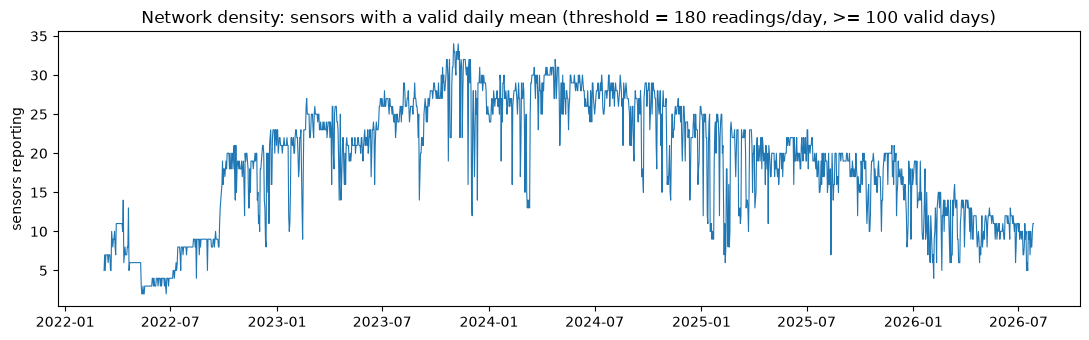

median sensors/day: 20
days with >= 10 sensors: 1345 of 1602


In [3]:
sensors_per_day = daily_matrix.notna().sum(axis=1)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(sensors_per_day.index, sensors_per_day.values, lw=0.8)
ax.set_ylabel("sensors reporting")
ax.set_title(f"Network density: sensors with a valid daily mean "
             f"(threshold = {MIN_READINGS_PER_DAY} readings/day, "
             f">= {MIN_VALID_DAYS} valid days)")
fig.tight_layout()
fig.savefig(OUT_FIGURES / "network_daily_density.png", dpi=150)
plt.show()

print(f"median sensors/day: {sensors_per_day.median():.0f}")
print(f"days with >= 10 sensors: {(sensors_per_day >= 10).sum()} of {len(sensors_per_day)}")

### Compute the CSI matrix

Pairs with fewer than `CSI_MIN_COMMON_DAYS` overlapping days stay NaN (white cells in the heatmap) — too little shared record to judge similarity.

In [4]:
csi, ncommon = csi_matrix(daily_matrix)

csi.round(3).to_csv(OUT_TABLES / "csi_matrix.csv")
ncommon.to_csv(OUT_TABLES / "csi_common_days.csv")

vals = csi.where(~np.eye(len(csi), dtype=bool)).stack()
print(f"pairs computed: {vals.notna().sum() // 2}  "
      f"(of {len(csi)*(len(csi)-1)//2} possible)")
print(f"network mean CSI: {vals.mean():.3f}   "
      f"min: {vals.min():.3f}   max: {vals.max():.3f}")

pairs computed: 844  (of 903 possible)
network mean CSI: 0.717   min: 0.000   max: 0.992


### CSI heatmap

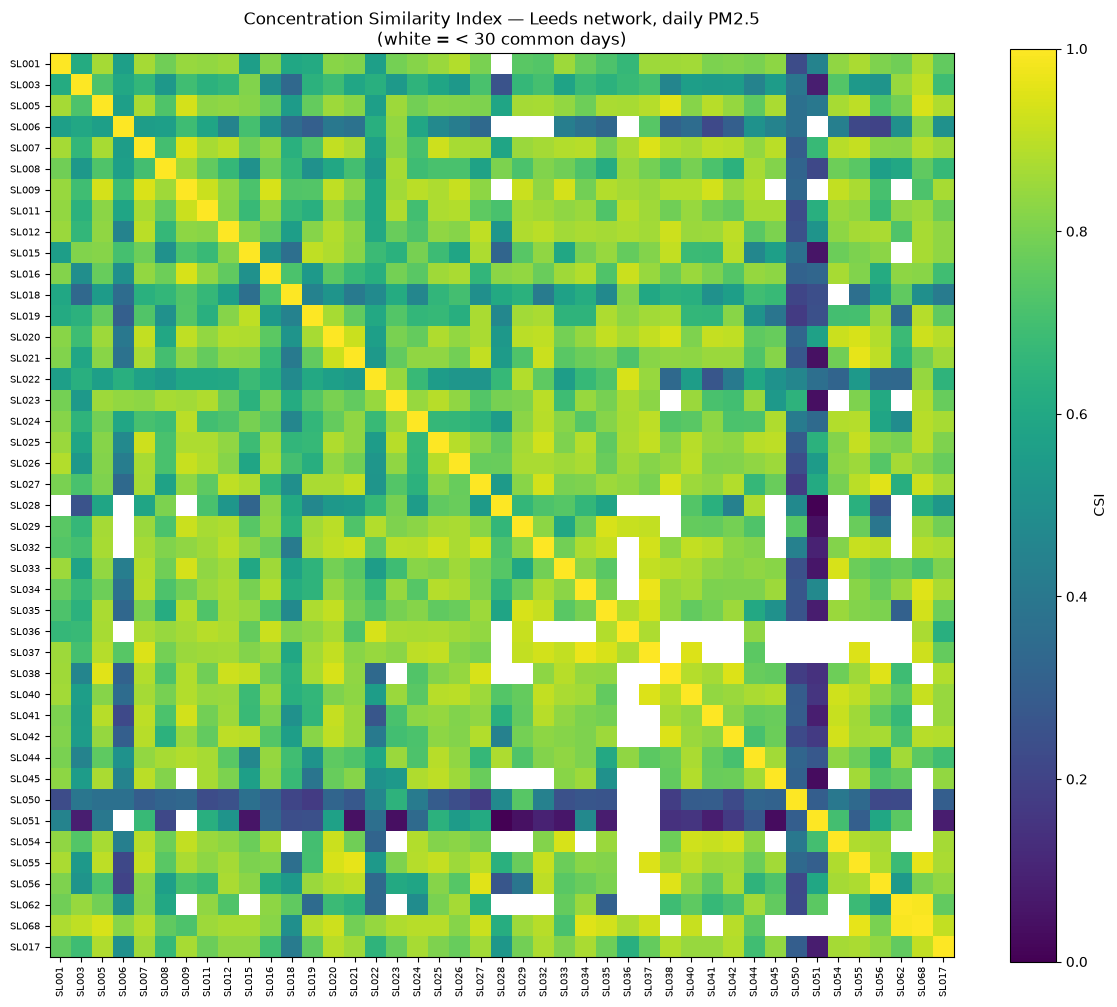

In [5]:
short = [short_code(c) for c in csi.columns]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(csi.values, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(len(short))); ax.set_xticklabels(short, rotation=90, fontsize=7)
ax.set_yticks(range(len(short))); ax.set_yticklabels(short, fontsize=7)
fig.colorbar(im, ax=ax, label="CSI")
ax.set_title("Concentration Similarity Index — Leeds network, daily PM2.5\n"
             f"(white = < {MIN_COMMON_DAYS} common days)")
fig.tight_layout()
fig.savefig(OUT_FIGURES / "csi_heatmap.png", dpi=150)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_20216\2511129044.py:17: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist, method="average")


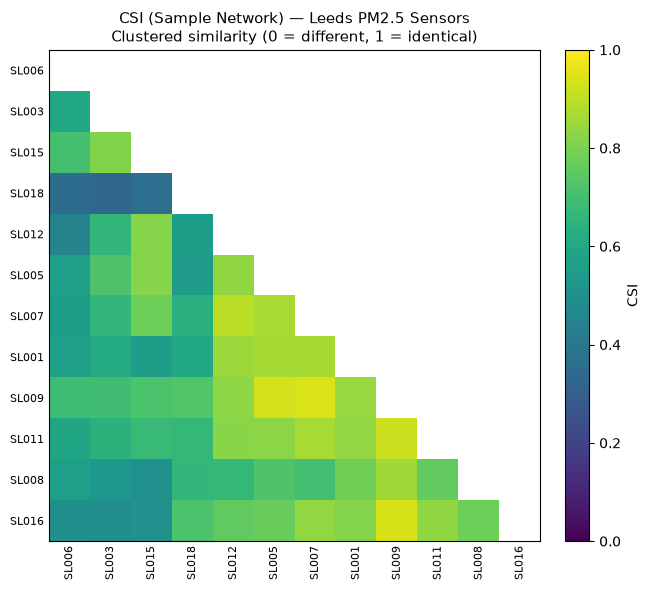

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list

# -------------------------
# STEP 1: TAKE A SUBSET 
# -------------------------
N = 12  
csi_sub = csi.iloc[:N, :N].copy()

# -------------------------
# STEP 2: CLUSTER ORDER (makes structure visible)
# -------------------------
dist = 1 - csi_sub.values
np.fill_diagonal(dist, 0)

link = linkage(dist, method="average")
order = leaves_list(link)

csi_sorted = csi_sub.iloc[order, order]

labels = [short_code(c) for c in csi_sorted.columns]

# -------------------------
# STEP 3: MASK UPPER TRIANGLE (remove redundancy)
# -------------------------
mask = np.triu(np.ones_like(csi_sorted, dtype=bool))
data = np.ma.masked_where(mask, csi_sorted.values)

# -------------------------
# STEP 4: PLOT
# -------------------------
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    data,
    vmin=0,
    vmax=1,
    cmap="viridis",
    interpolation="nearest"
)

# ticks
ax.set_xticks(range(N))
ax.set_yticks(range(N))

ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)

ax.tick_params(length=0)

# title
ax.set_title(
    "CSI (Sample Network) — Leeds PM2.5 Sensors\n"
    "Clustered similarity (0 = different, 1 = identical)",
    fontsize=11
)

# colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("CSI")

plt.tight_layout()

plt.savefig(
    OUT_FIGURES / "csi_sample_report.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Mean CSI per sensor, with pair counts

Low mean CSI on **many** pairs with **long** overlap is evidence; low mean CSI on a handful of short overlaps is not. The A/B disagreement rates from notebook 04 are merged in so both fault detectors sit in one table — the basis of the two-axis triage.

In [7]:
rank = sensor_ranking(csi, ncommon)
rank.index = [short_code(s) for s in rank.index]
rank.index.name = "sensor"

# merge the A/B fault-candidate table from notebook 04, if present
ab_path = OUT_TABLES / "fault_candidates.csv"
if ab_path.exists():
    ab = pd.read_csv(ab_path)
    ab["sensor"] = ab["sensor"].map(short_code)
    rank = rank.join(ab.set_index("sensor")["pct_ab_flag"], how="left")

rank.to_csv(OUT_TABLES / "csi_sensor_ranking.csv")

print("Least similar to the network (potential faults or unusual sites):")
print(rank.head(10).to_string())
print("\nMost similar:")
print(rank.tail(5).to_string())

Least similar to the network (potential faults or unusual sites):
        mean_csi  n_pairs  median_overlap_days
sensor                                        
SL051      0.307       37                 78.0
SL050      0.322       39                469.0
SL006      0.475       37                328.0
SL018      0.547       41                305.0
SL022      0.583       42                390.0
SL028      0.589       33                 88.0
SL003      0.598       42                360.0
SL019      0.669       42                554.0
SL008      0.684       42                450.0
SL062      0.684       33                220.0

Most similar:
        mean_csi  n_pairs  median_overlap_days
sensor                                        
SL032      0.811       38                184.0
SL009      0.828       38                152.0
SL036      0.836       26                 70.0
SL068      0.851       36                162.0
SL037      0.853       32                142.0


### Map — mean CSI at each sensor location

Fault signature: a dark point isolated among green neighbours. Genuine spatial signal: a dark *patch* of adjacent sensors. Fixed 0–1 colour scale to match the heatmap.

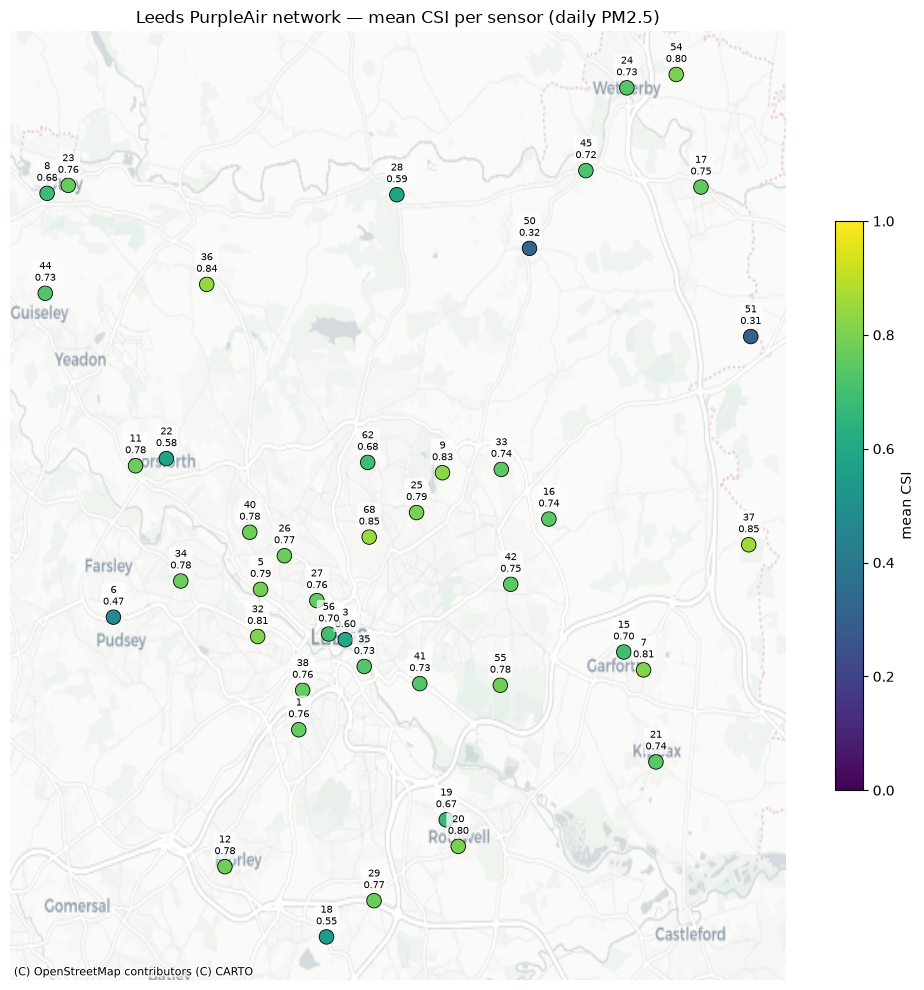

In [8]:
import contextily as cx

sensors = pd.read_csv(OUT_TABLES / "study_sensors.csv")
sensors["code"] = sensors["sensor_name"].map(short_code)
coords = sensors.set_index("code")[["lat", "lon"]]

m = coords.join(rank["mean_csi"], how="inner").dropna(subset=["mean_csi"])
missing = sorted(set(rank.index) - set(m.index))
if missing:
    print(f"no coordinates found for: {missing}")

R = 6378137.0
m["x"] = np.radians(m["lon"]) * R
m["y"] = np.log(np.tan(np.pi/4 + np.radians(m["lat"])/2)) * R

fig, ax = plt.subplots(figsize=(10, 10))
sc = ax.scatter(m["x"], m["y"], c=m["mean_csi"], cmap="viridis",
                vmin=0, vmax=1, s=110, edgecolor="black",
                linewidth=0.6, zorder=3)
for code, row in m.iterrows():
    ax.annotate(f"{code[2:].lstrip('0')}\n{row.mean_csi:.2f}",
                (row.x, row.y), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=7, zorder=4,
                bbox=dict(boxstyle="round,pad=0.15", fc="white",
                          ec="none", alpha=0.75))

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
fig.colorbar(sc, ax=ax, shrink=0.6, label="mean CSI")
ax.set_title("Leeds PurpleAir network — mean CSI per sensor (daily PM2.5)")
plt.tight_layout()
plt.savefig(OUT_FIGURES / "sensor_map_csi.png", dpi=200, bbox_inches="tight")
plt.show()

### CSI vs distance

Byrne (2024) found similarity does **not** decay simply with distance — location type dominates. If the same holds here, a low-CSI sensor can't excuse itself as merely 'far away', which strengthens the fault interpretation for isolated outliers like SL051.

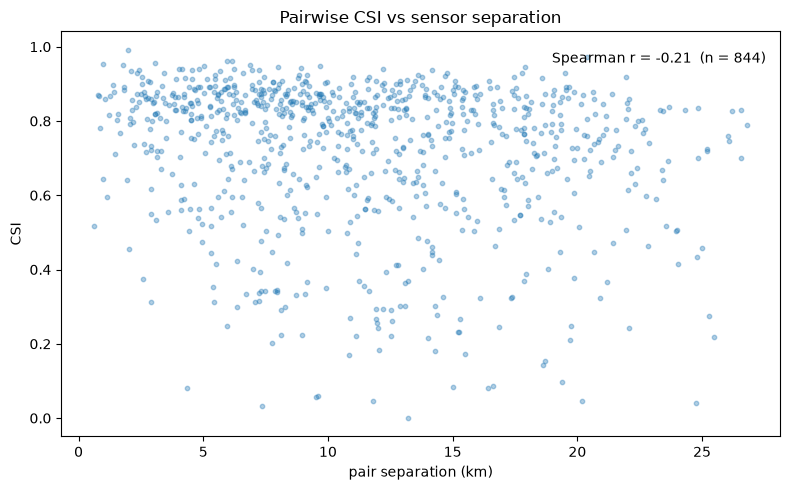

In [9]:
def haversine_km(lat1, lon1, lat2, lon2):
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi   = p2 - p1
    dlmb   = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlmb/2)**2
    return 2 * 6371.0 * np.arcsin(np.sqrt(a))

codes = [short_code(c) for c in csi.columns]
pairs = []
for i in range(len(codes)):
    for j in range(i + 1, len(codes)):
        ci, cj = codes[i], codes[j]
        if ci in coords.index and cj in coords.index:
            v = csi.iloc[i, j]
            if pd.notna(v):
                d = haversine_km(coords.loc[ci, "lat"], coords.loc[ci, "lon"],
                                 coords.loc[cj, "lat"], coords.loc[cj, "lon"])
                pairs.append({"a": ci, "b": cj, "km": d, "csi": v})
pairs = pd.DataFrame(pairs)
pairs.to_csv(OUT_TABLES / "csi_vs_distance.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pairs["km"], pairs["csi"], s=10, alpha=0.35)
ax.set_xlabel("pair separation (km)")
ax.set_ylabel("CSI")
ax.set_title("Pairwise CSI vs sensor separation")
r = pairs[["km", "csi"]].corr(method="spearman").iloc[0, 1]
ax.text(0.98, 0.95, f"Spearman r = {r:.2f}  (n = {len(pairs)})",
        ha="right", va="top", transform=ax.transAxes)
fig.tight_layout()
fig.savefig(OUT_FIGURES / "csi_vs_distance.png", dpi=150)
plt.show()

### Recent-window CSI — who is faulty *now*?

The matrix above scores each sensor over its whole lifetime, which answers "who has been unreliable overall" but can hide a sensor that worked well for years and broke recently (the fault is diluted by the healthy years). Recomputing the CSI on only the most recent 12 months answers the operational question instead: **which currently active sensors need a site visit?**

Dead sensors drop out automatically (no valid days in the window), so this is also, in effect, the currently-working-sensors matrix. The window is anchored to the last date in the daily matrix rather than to today, so the result is reproducible once the dataset is frozen. Pairs still need `MIN_COMMON_DAYS` overlapping days; with the thinner 2025–26 network, expect fewer valid pairs per sensor — the `n_pairs` column says how much evidence sits behind each score.

In [10]:
WINDOW_DAYS = 365
MIN_WINDOW_DAYS_PER_SENSOR = 60   # a sensor needs this many valid days in the window to be judged

end   = daily_matrix.index.max()
start = end - pd.Timedelta(days=WINDOW_DAYS)
recent = daily_matrix.loc[daily_matrix.index > start]

valid_days_recent = recent.notna().sum()
active = valid_days_recent[valid_days_recent >= MIN_WINDOW_DAYS_PER_SENSOR].index
recent = recent[active]

print(f"window: {start.date()} -> {end.date()}")
print(f"sensors active in window (>= {MIN_WINDOW_DAYS_PER_SENSOR} valid days): "
      f"{len(active)} of {daily_matrix.shape[1]}")

csi_recent, ncommon_recent = csi_matrix(recent)
rank_recent = sensor_ranking(csi_recent, ncommon_recent)
print(f"pairs with a valid recent CSI: {int(rank_recent['n_pairs'].sum() / 2)}")
rank_recent.head(10)


window: 2025-07-27 -> 2026-07-27
sensors active in window (>= 60 valid days): 23 of 43
pairs with a valid recent CSI: 242


,mean_csi,n_pairs,median_overlap_days
SL006,0.228,20,107.0
SL008_Westgate_Primary,0.238,17,96.0
SL050,0.243,22,188.0
SL022_Church_Lane_Horsforth,0.291,22,148.0
SL024_Wetherby_Town_Centre,0.295,22,187.0
SL005_Kirkstall_Valley_Primary,0.532,21,110.0
SL011,0.605,22,108.0
SL040,0.607,22,101.0
SL019_Cornwall_Crescent_Rothwell,0.617,19,74.0
SL016_Scholes_Main_Street,0.619,22,122.0


### Lifetime vs recent — chronic faults vs new faults

Joining the two rankings separates three groups. **Chronic** sensors sit low on both scores (SL051-type: broken for as long as we can see). **Newly developing faults** were fine over their lifetime but score low in the recent window — these are the urgent, actionable site-visit candidates, because the fault is current and the sensor is still reporting. Sensors missing from the recent ranking are **inactive**: no longer reporting enough days to judge (a site visit there is about restoring the sensor, not diagnosing its data).

In the scatter, the diagonal is "no change"; points well below it are deteriorating.

In [11]:
cmp = (rank[["mean_csi"]].rename(columns={"mean_csi": "lifetime_csi"})
       .join(rank_recent[["mean_csi", "n_pairs"]]
             .rename(columns={"mean_csi": "recent_csi", "n_pairs": "recent_pairs"}),
             how="left"))
cmp["change"] = (cmp["recent_csi"] - cmp["lifetime_csi"]).round(3)

active_cmp   = cmp.dropna(subset=["recent_csi"]).sort_values("recent_csi")
inactive     = cmp[cmp["recent_csi"].isna()].index

print(f"inactive in the last {WINDOW_DAYS} days ({len(inactive)}): "
      + ", ".join(short_code(s) for s in inactive))
print("\nActive sensors, least network-consistent first:")
active_cmp.round(3)


inactive in the last 365 days (31): SL018, SL022, SL028, SL003, SL019, SL008, SL015, SL045, SL024, SL041, SL035, SL021, SL033, SL016, SL017, SL001, SL023, SL027, SL038, SL029, SL055, SL012, SL005, SL025, SL054, SL007, SL032, SL009, SL036, SL068, SL037

Active sensors, least network-consistent first:


,lifetime_csi,recent_csi,recent_pairs,change
sensor,,,,
SL006,0.475,0.228,20.0,-0.247
SL050,0.322,0.243,22.0,-0.079
SL011,0.775,0.605,22.0,-0.170
SL040,0.778,0.607,22.0,-0.171
SL020,0.796,0.625,22.0,-0.171
SL056,0.699,0.637,22.0,-0.062
SL062,0.684,0.638,22.0,-0.046
SL051,0.307,0.656,18.0,0.349
SL042,0.746,0.657,20.0,-0.089


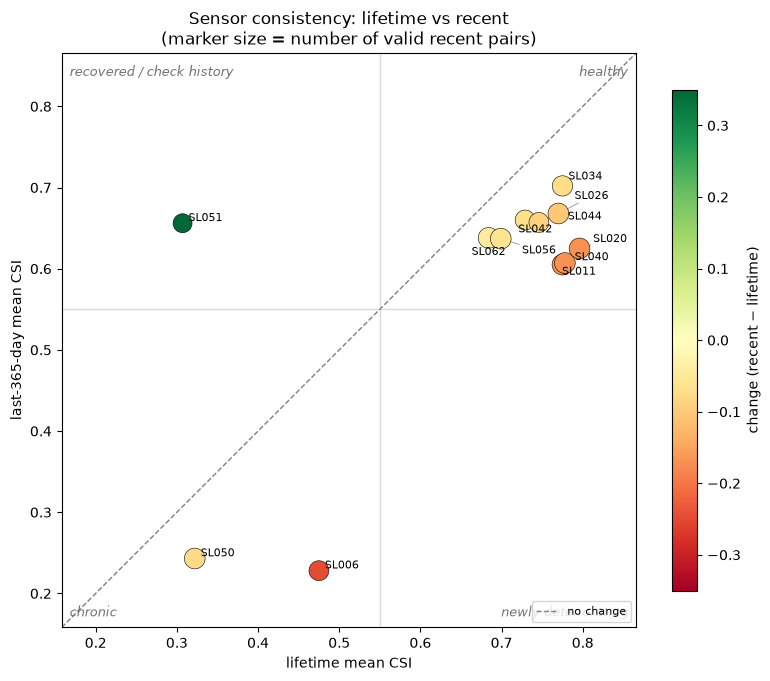

saved figure + table


In [12]:
from matplotlib import colors as mcolors

m = cmp.dropna(subset=["recent_csi"]).copy()

lo = max(0.0, min(m["lifetime_csi"].min(), m["recent_csi"].min()) - 0.07)
hi = min(1.0, max(m["lifetime_csi"].max(), m["recent_csi"].max()) + 0.07)
FAULT = 0.55   # below this = fault territory (healthy band sits at 0.7-0.85)

fig, ax = plt.subplots(figsize=(8, 7))

# quadrant guides + labels
ax.axhline(FAULT, color="0.85", lw=1, zorder=1)
ax.axvline(FAULT, color="0.85", lw=1, zorder=1)
qstyle = dict(fontsize=9, color="0.45", style="italic")
ax.text(hi - 0.01, hi - 0.015, "healthy", ha="right", va="top", **qstyle)
ax.text(hi - 0.01, lo + 0.01, "newly deteriorating", ha="right", va="bottom", **qstyle)
ax.text(lo + 0.01, lo + 0.01, "chronic", ha="left", va="bottom", **qstyle)
ax.text(lo + 0.01, hi - 0.015, "recovered / check history", ha="left", va="top", **qstyle)

ax.plot([lo, hi], [lo, hi], "--", color="grey", lw=1, zorder=2, label="no change")

# colour = change, size = evidence (number of valid recent pairs)
norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-0.35, vmax=0.35)
sc = ax.scatter(m["lifetime_csi"], m["recent_csi"],
                c=m["change"], cmap="RdYlGn", norm=norm,
                s=25 + 9 * m["recent_pairs"], edgecolor="k", lw=0.4, zorder=3)
cb = fig.colorbar(sc, ax=ax, shrink=0.8)
cb.set_label("change (recent \u2212 lifetime)")

# label every point; adjustText untangles collisions if installed
try:
    from adjustText import adjust_text
    texts = [ax.text(r["lifetime_csi"], r["recent_csi"], short_code(s), fontsize=8)
             for s, r in m.iterrows()]
    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle="-", color="grey", lw=0.5))
except ImportError:   # fallback: alternate offsets around the point
    offsets = [(6, 5), (6, -11), (-34, 5), (-34, -11)]
    for k, (s, r) in enumerate(m.iterrows()):
        dx, dy = offsets[k % 4]
        ax.annotate(short_code(s), (r["lifetime_csi"], r["recent_csi"]),
                    xytext=(dx, dy), textcoords="offset points", fontsize=8)

ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_aspect("equal")
ax.set_xlabel("lifetime mean CSI")
ax.set_ylabel(f"last-{WINDOW_DAYS}-day mean CSI")
ax.set_title("Sensor consistency: lifetime vs recent\n"
             "(marker size = number of valid recent pairs)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(OUT_FIGURES / "csi_lifetime_vs_recent.png", dpi=200, bbox_inches="tight")
plt.show()

active_cmp.to_csv(OUT_TABLES / "csi_lifetime_vs_recent.csv")
print("saved figure + table")
